In [1]:
import os
import pandas as pd
import subprocess
import sys

# --- Download the files ---
# Run shell commands using subprocess (works in normal Python)
subprocess.run(["curl", "-O", "https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/graphing.py"])
subprocess.run(["curl", "-O", "https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-boot-harness.csv"])

# --- Install required library if missing ---
# You can skip this if you've already installed statsmodels via terminal or PyCharm settings
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels"])

# --- Create the dataset ---
data = {
    'boot_size': [39, 38, 37, 39, 38, 35, 37, 36, 35, 40, 40, 36, 38, 39, 42, 42, 36, 36, 35, 41,
                  42, 38, 37, 35, 40, 36, 35, 39, 41, 37, 35, 41, 39, 41, 42, 42, 36, 37, 37, 39,
                  42, 35, 36, 41, 41, 41, 39, 39, 35, 39],
    'harness_size': [58, 58, 52, 58, 57, 52, 55, 53, 49, 54, 59, 56, 53, 58, 57, 58, 56, 51, 50, 59,
                     59, 59, 55, 50, 55, 52, 53, 54, 61, 56, 55, 60, 57, 56, 61, 58, 53, 57, 57, 55,
                     60, 51, 52, 56, 55, 57, 58, 57, 51, 59]
}

dataset = pd.DataFrame(data)

# --- Print the dataset ---
print(dataset)

# Load a library to do the hard work for us
import statsmodels.formula.api as smf

# Define our formula using the correct syntax
# This says that boot_size is explained by harness_size
formula = "boot_size ~ harness_size"

# Create the model, but don't train it yet
model = smf.ols(formula=formula, data=dataset)

# Check if the model has parameters yet
if not hasattr(model, 'params'):
    print("Model selected but it does not have parameters set. We need to train it!")
# Train (fit) the model so that it creates a line that
# fits our data. This method does the hard work for us.
fitted_model = model.fit()

# Print information about our model now that it has been fit
print("The following model parameters have been found:\n" +
      f"Line slope: {fitted_model.params[1]}\n" +
      f"Line intercept: {fitted_model.params[0]}")
import matplotlib.pyplot as plt

# Show a scatter plot of the actual data points
plt.scatter(dataset["harness_size"], dataset["boot_size"], label="Data points")

# Add the fitted regression line
plt.plot(
    dataset["harness_size"],
    fitted_model.params['Intercept'] + fitted_model.params['harness_size'] * dataset["harness_size"],
    color='r',
    label='Fitted line'
)

# Add labels, title, and legend
plt.xlabel("Harness Size (cm)")
plt.ylabel("Boot Size")
plt.title("Boot Size vs Harness Size (with regression line)")
plt.legend()

# Show the plot
plt.show()
# harness_size states the size of the harness we are interested in
harness_size = {'harness_size': [52.5]}

# Convert to DataFrame (required by statsmodels)
import pandas as pd
harness_df = pd.DataFrame(harness_size)

# Use the model to predict what size of boots the dog will fit
approximate_boot_size = fitted_model.predict(harness_df)

# Print the result
print(f"Predicted boot size for a harness size of 52.5 cm: {approximate_boot_size[0]:.2f}")


ModuleNotFoundError: No module named 'pandas'

In [2]:
!pip install pandas statsmodels matplotlib



^C
  Using cached statsmodels-0.14.5-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached matplotlib-3.10.6-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.16.2-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached patsy-1.0.1-py2.py3-none-any.whl.metadata (3.3 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp311-cp311-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp311-cp311-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-11.3.0-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
Using cached statsmodels-0.14.5-cp311-cp311-win_amd64.whl (9.6 MB)
Using cached matplotlib-3.10.6-cp311-cp311-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.6

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf


In [4]:
# You can use curl or wget directly in Jupyter with "!" prefix (no subprocess needed)
!curl -O https://raw.githubusercontent.com/MicrosoftDocs/mslearn-introduction-to-machine-learning/main/Data/doggy-boot-harness.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   838  100   838    0     0   1174      0 --:--:-- --:--:-- --:--:--  1190


In [5]:
data = {
    'boot_size': [39, 38, 37, 39, 38, 35, 37, 36, 35, 40, 40, 36, 38, 39, 42, 42, 36, 36, 35, 41,
                  42, 38, 37, 35, 40, 36, 35, 39, 41, 37, 35, 41, 39, 41, 42, 42, 36, 37, 37, 39,
                  42, 35, 36, 41, 41, 41, 39, 39, 35, 39],
    'harness_size': [58, 58, 52, 58, 57, 52, 55, 53, 49, 54, 59, 56, 53, 58, 57, 58, 56, 51, 50, 59,
                     59, 59, 55, 50, 55, 52, 53, 54, 61, 56, 55, 60, 57, 56, 61, 58, 53, 57, 57, 55,
                     60, 51, 52, 56, 55, 57, 58, 57, 51, 59]
}

dataset = pd.DataFrame(data)
dataset.head()


,boot_size,harness_size
0,39,58
1,38,58
2,37,52
3,39,58
4,38,57


In [6]:
formula = "boot_size ~ harness_size"
model = smf.ols(formula=formula, data=dataset)
fitted_model = model.fit()

print("Model trained successfully!")
print(f"Slope: {fitted_model.params['harness_size']:.4f}")
print(f"Intercept: {fitted_model.params['Intercept']:.4f}")


Model trained successfully!
Slope: 0.5859
Intercept: 5.7191


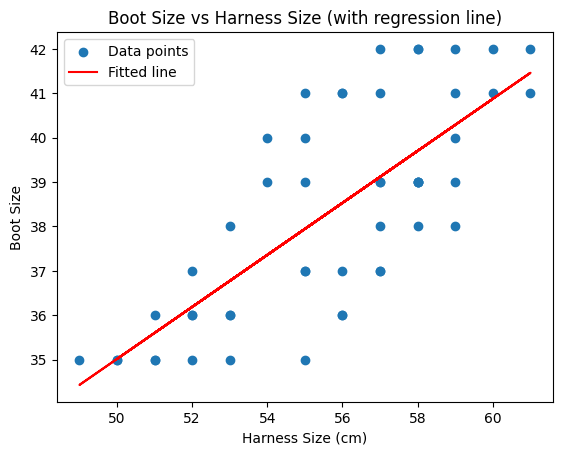

In [7]:
%matplotlib inline

plt.scatter(dataset["harness_size"], dataset["boot_size"], label="Data points")
plt.plot(
    dataset["harness_size"],
    fitted_model.params['Intercept'] + fitted_model.params['harness_size'] * dataset["harness_size"],
    color='red', label='Fitted line'
)
plt.xlabel("Harness Size (cm)")
plt.ylabel("Boot Size")
plt.title("Boot Size vs Harness Size (with regression line)")
plt.legend()
plt.show()


In [8]:
harness_df = pd.DataFrame({'harness_size': [52.5]})
predicted = fitted_model.predict(harness_df)

print(f"Predicted boot size for a harness size of 52.5 cm: {predicted[0]:.2f}")


Predicted boot size for a harness size of 52.5 cm: 36.48
